# GPT Architecture: FEEDFORWARD NETWORK WITH GELU activation function

In [2]:
import torch
import torch.nn as nn
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1+torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi))*(x + 0.044715 * torch.pow(x,3))))

To get an idea of what this GELU function looks like and how it compares to the ReLU function, let's plot these functions side by side:

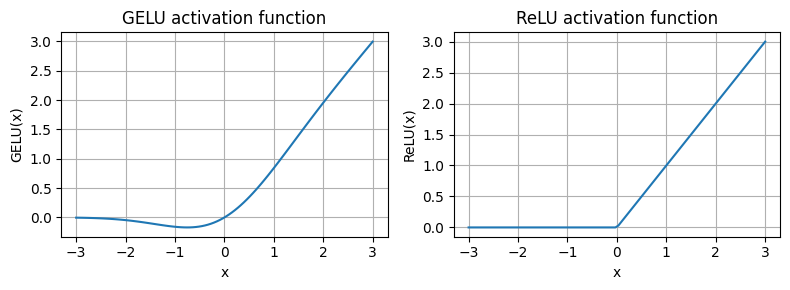

In [3]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

#Some sample data
x= torch.linspace(-3,3,100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8,3))
for i, (y,label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]),1):
  plt.subplot(1,2,i)
  plt.plot(x,y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label}(x)")
  plt.grid(True)

plt.tight_layout()
plt.show()

As we can see in the resulting plot, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero.

GELU is a smooth, nonlinear function that approximates ReLU but with a non-zero gradient for negative values.

The smoothness of GELU, as shown in the above figure, can lead to better optimization properties during training, as it allows for more nuanced adjustments to the model's parameters.

In contrast, ReLU has a sharp corner at zero, which can sometimes make optimization harder, especially in networks that are very deep or have complex architectures.

Moreover, unlike RELU, which outputs zero for any negative input, GELU allows for a small, non-zero output for negative values.

This characteristic means that during the training process, neurons that receive negative input can still contribute to the learning process, albeit to a lesser extent than positive inputs.

Useing the GELU function to implement the small neural network module, FeedForward, that we will be using in the LLM's transformer block later:

# Feed Forward Neural Network- Linear Layer

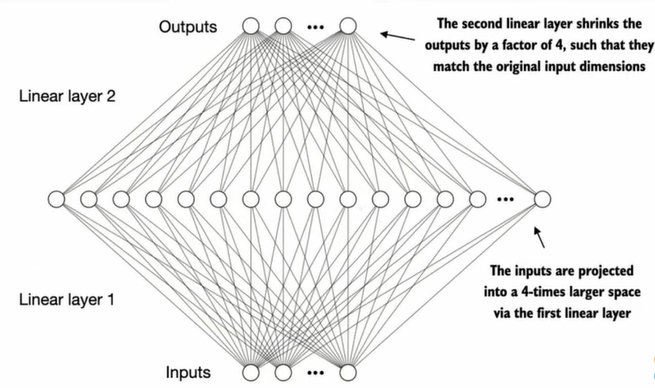

The above is an expansion-contraction fashion neural network, that allows us to preserve the size of the input but at the same time they allow for a rich exploration of space by scaling the given inputs to a larger dimensions ie, given example that the input is projected into 4 times larger space and again it is compressed to the original dimension on the output as the input. Due to this expansion we could capture more properties.

Unlike attention meachanism where we consider the relation of a token with other tokens, here in neural networks we do not consider the relation between neighbouring tokens.

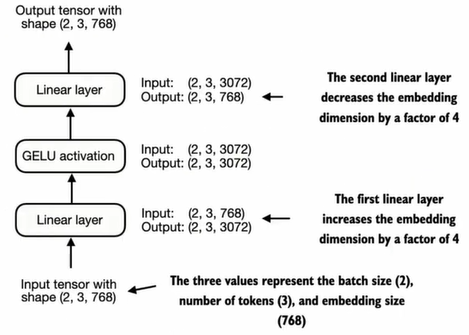

In [4]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "context_length": 1024,
    "dropout": 0.1,
    "qkv_bias": False
}

In [5]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), #Expansion
        GELU(), #activation
        nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]), #contraction
    )

  def forward(self,x):
    return self.layers(x)

In [6]:
#check the dimension
print(GPT_CONFIG_124M["emb_dim"])

768


As we can see in the preceding code, the FeedForward module is a small neural network consisting of two Linear layers and a GELU activation function.

In the 124 million parameter GPT model, it receives the input batches with tokens that have an embedding size of 768 each via the GPT_CONFIG_124M dictionary where GPT_CONFIG_124M["emb_dim"] = 768.

Using the GELU function to implement the small neural network module, FeedForward, that we will be using in the LLM's transformer block later:

In [7]:
ffn = FeedForward(GPT_CONFIG_124M)
x= torch.rand(2,3,768) #A
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


The FeedForward module we implemented in this section plays a crucial role in enhancing the model's ability to learn from and generalize the data.

Although the input and output dimensions of this module are the same, it internally expands the embedding dimension into a higher-dimensional space through the first linear layer.

This expansion is followed by a non-linear GELU activation, and then a contraction back to the original dimension with the second linear transformation.

Such a design allows for the exploration of a richer representation space.

Moreover, the uniformity in input and output dimensions simplifies the architecture by enabling the stacking of multiple layers, as we will do later, without the need to adjust dimensions between them, thus making the model more scalable.